In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

#connects to our shared google drive folder that has the csv. Professor I have added you to the shared drive so you can run the code
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
path = '/content/drive/Shareddrives/CS133 Group 6/CS 133 Project Group 6/diabetes_dataset.csv'
df= pd.read_csv(path)
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [8]:
#Makes a column called race to make it easier to groupby race
def race_to_col(row):
  if row['race:AfricanAmerican'] == 1:
    return 'African American'
  elif row['race:Asian'] == 1:
    return 'Asian'
  elif row['race:Hispanic'] == 1:
    return 'Hispanic'
  elif row['race:Caucasian'] == 1:
    return 'Caucasian'
  else:
    return 'Other'

df['race'] = df.apply(race_to_col, axis='columns')
df.head(3)

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,race
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,Other
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Asian
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,Other


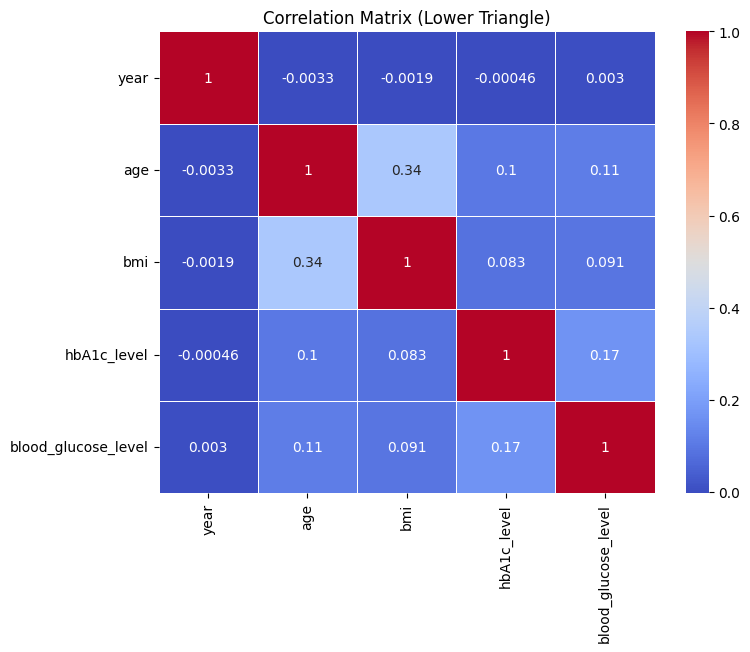

In [9]:
#transfered from PA2

# Select the variables
corr_vars = ["year", "age", "bmi", "hbA1c_level", "blood_glucose_level"]

# Compute correlation matrix
corr_matrix = df[corr_vars].corr()


# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix (Lower Triangle)")
plt.show()


In [10]:
#change target columns to see value types
target_column = 'gender'
target_balance = df[target_column].value_counts()
target_balance

,count
gender,
Female,58552
Male,41430
Other,18


In [11]:
#groupby to see diabetes count in all races in dataset

#total = df.groupby('race')['diabetes'].sum()
result = df.loc[df['diabetes'] == 1].groupby('race')['diabetes'].sum()

print(result)

race
African American    1768
Asian               1743
Caucasian           1670
Hispanic            1676
Other               1643
Name: diabetes, dtype: int64


In [12]:
#Encode gender as int values for corr

GENDER_ENCODING = {
    "Male": 0,
    "Female": 1,
    "Other": 2
}
df['gender']= df['gender'].map(GENDER_ENCODING)
df['gender'].value_counts()

,count
gender,
1,58552
0,41430
2,18


In [13]:
#if you want to remove race from the corr plot

#df_no_race = df.copy()
#df_no_race.drop(columns=df.loc[:,'race:AfricanAmerican':'race:Other'], inplace=True)
#df_no_race.head()

#plt.figure(figsize=(14,9))
#corr=df_no_race.corr(numeric_only=True)
#sns.heatmap(corr,annot=True,cmap='Blues',linewidths=0.6,fmt=".1f",linecolor="black")
#plt.show()

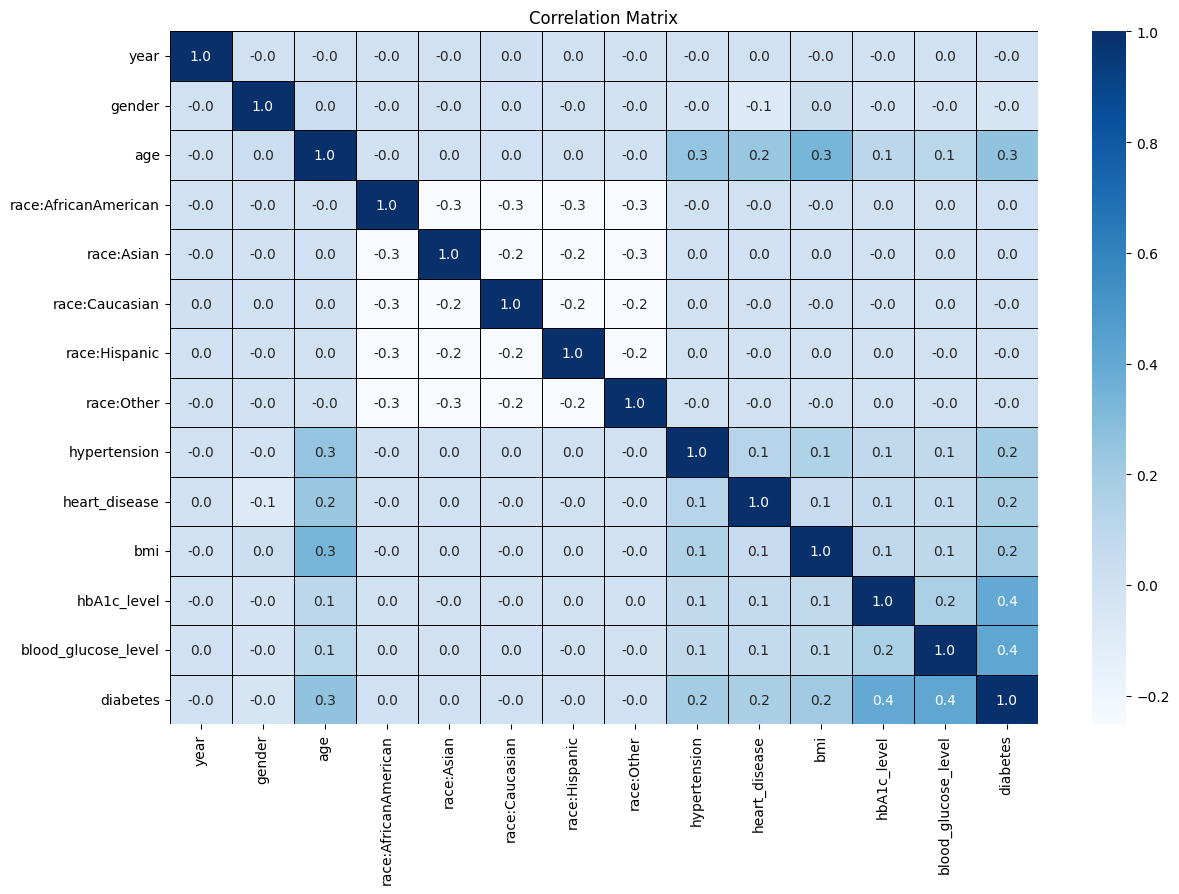

In [14]:
plt.figure(figsize=(14,9))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='Blues',linewidths=0.6,fmt=".1f",linecolor="black")
plt.title('Correlation Matrix')
plt.show()

In [15]:
#see correlation values for diabetes

corr_pairs=corr.unstack()
corr_pairs['diabetes'].sort_values(ascending = False)

,0
diabetes,1.000000
blood_glucose_level,0.419558
hbA1c_level,0.400660
age,0.258008
bmi,0.214357
hypertension,0.197823
heart_disease,0.171727
race:AfricanAmerican,0.004378
race:Asian,0.003739
race:Hispanic,-0.001301


## Other misc graphs I made while writing:
- pairplot
- scatterplot with prediabetic levels shaded

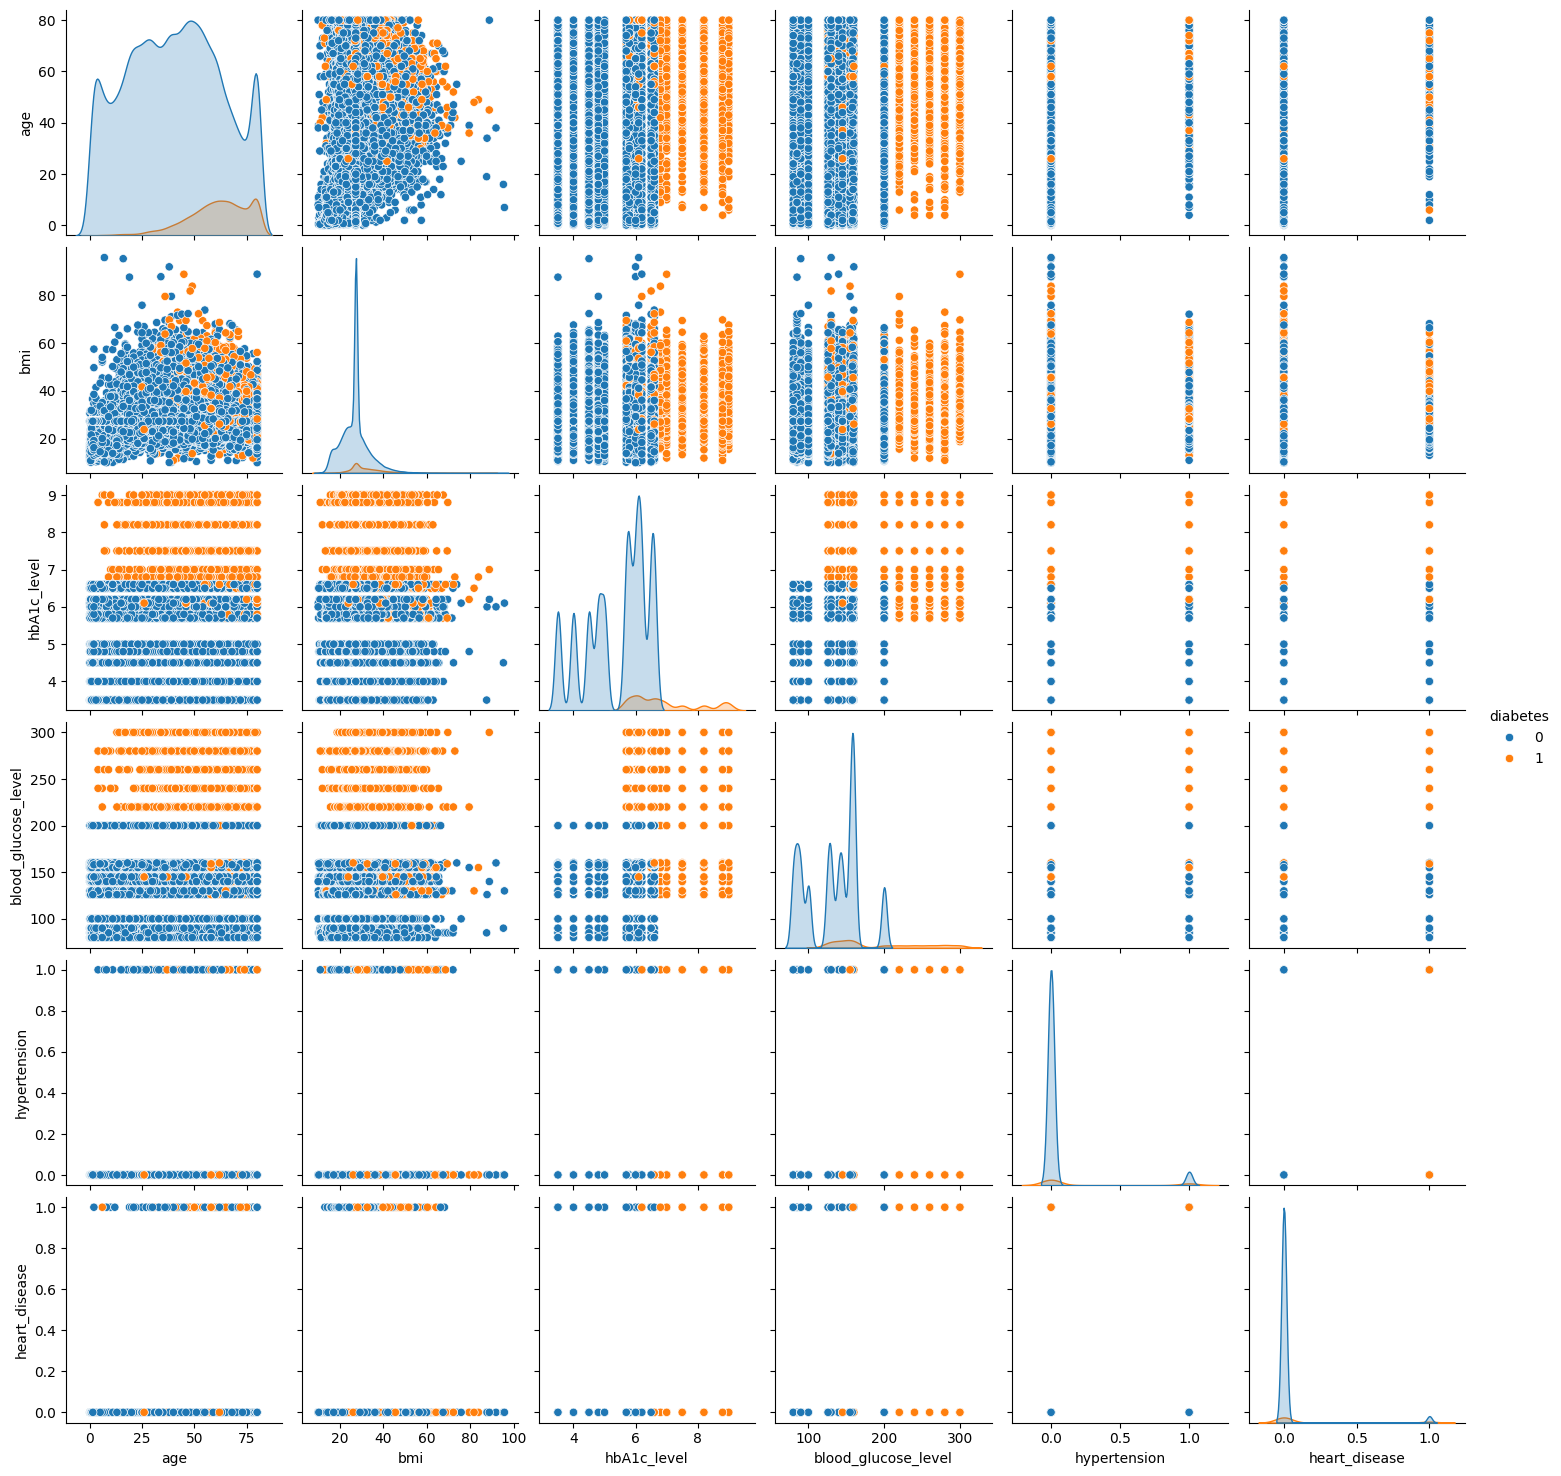

In [16]:
sns.pairplot(df[['age', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'hypertension','heart_disease', 'diabetes']], hue='diabetes')
plt.show()

Text(0.5, 0, 'Age')

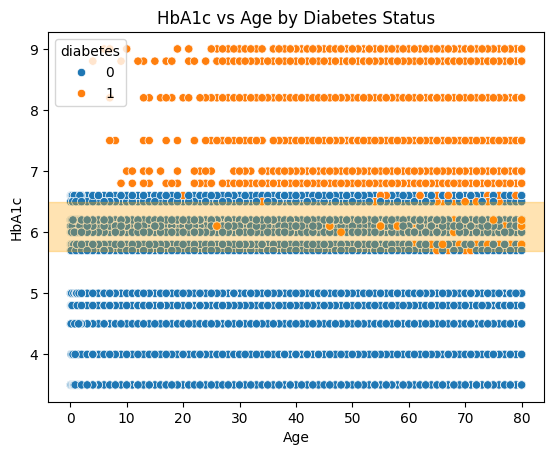

In [17]:
ax = sns.scatterplot(
    data=df,
    y='hbA1c_level',
    x='age',
    hue='diabetes',
)
# shades prediabetic region for HbA1c levels
ax.axhspan(5.7, 6.5, color='orange', alpha=0.3)


plt.title("HbA1c vs Age by Diabetes Status")
plt.ylabel('HbA1c')
plt.xlabel('Age')

In [18]:


race_cols = [
    "race:AfricanAmerican",
    "race:Asian",
    "race:Caucasian",
    "race:Hispanic",
    "race:Other"
]

# Create Race slider
race_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(race_cols) - 1,
    step=1,
    description="Race Index:",
    continuous_update=False
)

# Create Age Slider (5 year groups)
age_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=19,
    step=1,
    description="Age Group:",
    continuous_update=False
)

def show_stats(race_index, age_group_index):
    race_col = race_cols[race_index]
    race_name = race_col.replace("race:", "")

    age_min = age_group_index * 5
    age_max = age_min + 4

    subset = df[
        (df[race_col] == 1) &
        (df["age"] >= age_min) &
        (df["age"] <= age_max)
    ]

    print(f"=== {race_name} | Ages {age_min}–{age_max} ===")

    if subset.empty:
        print("No data available for this combination.")
        return

    avg_age = subset["age"].mean()
    avg_bmi = subset["bmi"].mean()
    avg_hba1c = subset["hbA1c_level"].mean()
    avg_glucose = subset["blood_glucose_level"].mean()
    avg_hypertension = subset["hypertension"].mean()
    avg_heart_disease = subset["heart_disease"].mean()
    avg_diabetes_rate = subset["diabetes"].mean()

    plot = sns.scatterplot(
        subset,
        x="hbA1c_level",
        y="bmi",
        hue="diabetes"
    )

    plot.axvspan(5.7, 6.5, color="orange", alpha=0.2)
    plot.axvspan(6.5, 9.5, color="red", alpha=0.1)

    plt.title(f"HbA1c Level vs BMI for {race_name} | Ages {age_min}–{age_max}")
    plt.xlabel("HbA1c Level")
    plt.ylabel("BMI")

    print(f"=== {race_name} ===")
    print(f"Average Age: {avg_age:.2f}")
    print(f"Average BMI: {avg_bmi:.2f}")
    print(f"Average HbA1c Level: {avg_hba1c:.2f}")
    print(f"Average Blood Glucose Level: {avg_glucose:.2f}")
    print(f"Hypertension Rate: {avg_hypertension:.3f}")
    print(f"Heart Disease Rate: {avg_heart_disease:.3f}")
    print(f"Diabetes Rate: {avg_diabetes_rate:.3f}")

    plt.show()


# Link slider to function
widgets.interact(show_stats, race_index=race_slider, age_group_index=age_slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Race Index:', max=4), IntSlider…

<function __main__.show_stats(race_index, age_group_index)>